# Bipolar Cell Simulation

## Imports
The dataset comes from kaggle, so by using their "kagglehub" package the data can be downloaded directly to this working directory. If the dataset is already present, it will not be redownloaded.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balraj98/berkeley-segmentation-dataset-500-bsds500", output_dir="./dataset")

c:\Coding\School\Research\bipolar-cell-simulation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve
        local, _ = urlretrieve(url, filename)
        print('Downloaded ' + local)

download('https://github.com/AllenDowney/ModSimPy/raw/master/' +
         'modsim.py')

from modsim import *

import cv2
import glob
import numpy as np
from matplotlib import pyplot as plt

## Dataset Loading
Having the dataset in the directory is not enough. Each individual image must be loaded in and represented in some way using Python. OpenCV is used in combination with glob in order to iteratively load in folders full of .jpg images. A sample image from the test dataset is displayed at the bottom of the cell.

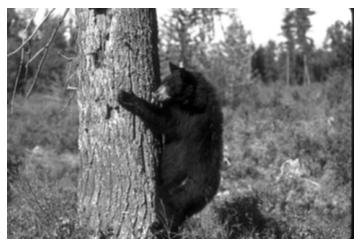

In [6]:
directory = "./dataset/images/test"

images = []
for filename in glob.iglob(f'{directory}/*.jpg'):
    # Load the image in as grayscale
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)
    # Apply gaussian blur filter to image
    image = cv2.GaussianBlur(image, (3,3), 2)
    images.append(image)

# Test image output
plt.imshow(images[1], cmap='gray')
plt.axis('off')
plt.show()


## Model Testing
The model was then tested on a single image, the same image displayed in the above dataset loading section. The model begins by applying a Laplacian filter to the image, which is a zero-sum 3x3 kernel with a high weight for the center pixel and low weight for the edge pixels. The middle pixel may be weighted -8 while the others are each weighted 1 for a 3x3 kernel for example. Then, normalization is applied to the resulting image since the Laplacian filter results in values far outside of the typical color bounds of 0 to 1.0. Finally, the images are displayed after each step is completed.

(np.float64(-0.5), np.float64(480.5), np.float64(320.5), np.float64(-0.5))

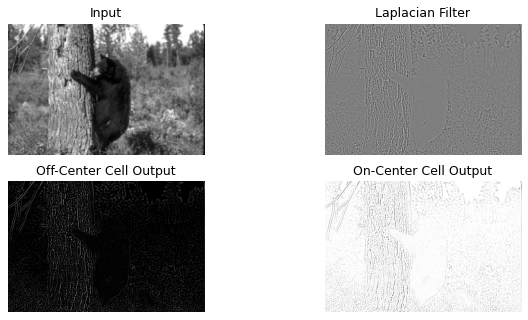

In [7]:
laplacian = cv2.Laplacian(images[1], cv2.CV_64F, ksize=1)

def off_center_cell(x):
    x = x*(255/x.max())
    return np.maximum(x, 0)

def on_center_cell(x):
    x = x*(255/x.min())
    return np.minimum(x, 0)

off_center = off_center_cell(laplacian)

on_center = on_center_cell(laplacian)

fig, ax = plt.subplots(2, 2, figsize=(10, 5))

ax[0][0].imshow(images[1], cmap='gray')
ax[0][0].set_title('Input')
ax[0][0].axis('off')

ax[0][1].imshow(laplacian, cmap='gray')
ax[0][1].set_title('Laplacian Filter')
ax[0][1].axis('off')

ax[1][0].imshow(off_center, cmap='gray')
ax[1][0].set_title('Off-Center Cell Output')
ax[1][0].axis('off')

ax[1][1].imshow(on_center, cmap='gray')
ax[1][1].set_title('On-Center Cell Output')
ax[1][1].axis('off')



## Retinal Ganglion Cell (RGC) Output
The retinal pathway goes from bipolar cells to RGCs. Bipolar cells themselves do not create action potentials, or spikes. Instead, they send graded potentials to the RGCs, which then propagate action potentials down the visual pathway to the brain. First, the image is downsampled since a real retina has many more photoreceptors than it does RGCs.

92.99636406633306


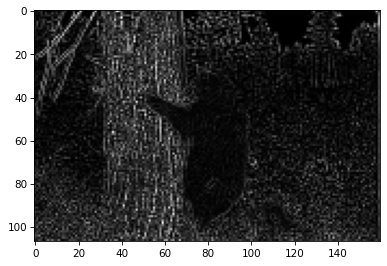

In [ ]:
new_x = int(off_center.shape[0]/3)
new_y = int(off_center.shape[1]/3)
downsampled = cv2.resize(off_center, (new_y, new_x), interpolation=cv2.INTER_AREA)
print(downsampled.max())
plt.imshow(downsampled, cmap='gray')

Im:  92.99636406633306


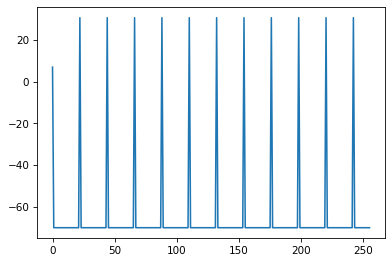

In [54]:
neuron = System (e_l = 7,
                g_l = 0.1,
                v_thresh = 40,
                v_reset = -70,
                t_ref = 20)

def update_voltage(v_m, i_m, neuron):
  delta_v_m = neuron.g_l*(neuron.e_l - v_m) + i_m
  new_v_m = v_m + delta_v_m
  return new_v_m

def run_simulation(neuron, update, i_m):
  neuron_data = TimeSeries()
  time_steps = 255
  neuron_data[0] = neuron.e_l
  wait_t = 0
  for t in range(time_steps):
    if wait_t <= 0:
      new_v_m = update(neuron_data[t], i_m, neuron)
      if new_v_m >= neuron.v_thresh:
        new_v_m = neuron.v_reset
        wait_t = neuron.t_ref
    else:
      wait_t -= 1
    neuron_data[t+1] = new_v_m
  return neuron_data

i_m = downsampled.max()
print("Im: ", i_m)
results = run_simulation(neuron, update_voltage, i_m)
plt.plot(results)